# 04 · XGBoost y CatBoost

Partición 80/10/10 del train etiquetado en `X_train`, `X_val`, `X_test`. Búsqueda de hiperparámetros con `X_val`; comparación final de ambos modelos en `X_test` con matriz de confusión, F1, precisión, recall y curva precisión-recall. El archivo de Kaggle (enero 2024) se llama `oot` para no confundirlo con `X_test`.

1. Partición · 2. Preparación · 3. XGBoost · 4. CatBoost · 5. Comparación en test · 6. Modelo final y archivos

In [1]:
import warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, precision_recall_curve, average_precision_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 50)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"; OUT = ROOT / "outputs"; OUT.mkdir(exist_ok=True); (ROOT / "models").mkdir(exist_ok=True)

C_BLUE, C_ORANGE, C_GRAY, C_MUTED = "#2a78d6", "#eb6834", "#c9c8c3", "#52514e"
mpl.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_GRAY,
                     "axes.grid": True, "grid.color": "#ececea", "axes.axisbelow": True, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.titlelocation": "left", "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED})
SEED = 42

## 1. Partición 80/10/10

Estratificada por la etiqueta, semilla 42. `X_train` para ajustar, `X_val` para elegir hiperparámetros y umbral, `X_test` solo para la evaluación final.

In [2]:
train = pd.read_parquet(DATA / "train.parquet")
oot = pd.read_parquet(DATA / "test.parquet")
FEATS = pd.read_csv(DATA / "features_seleccionadas.csv").feature.tolist()
TARGET = "var_rpta_alt"
CAT = [c for c in FEATS if str(train[c].dtype) == "category"]
NUM = [c for c in FEATS if c not in CAT]
for c in CAT:
    cats = pd.api.types.union_categoricals([train[c], oot[c]]).categories
    train[c] = pd.Categorical(train[c], categories=cats); oot[c] = pd.Categorical(oot[c], categories=cats)

X, y = train[FEATS], train[TARGET]
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

print(f"Variables: {len(FEATS)} = {len(NUM)} numéricas + {len(CAT)} categóricas")
for n, yy in [("X_train", y_train), ("X_val", y_val), ("X_test", y_test)]:
    print(f"{n}: {len(yy):,} filas ({len(yy)/len(y):.0%}), tasa de 1 = {yy.mean():.3f}")

Variables: 77 = 62 numéricas + 15 categóricas
X_train: 454,600 filas (80%), tasa de 1 = 0.480
X_val: 56,825 filas (10%), tasa de 1 = 0.480
X_test: 56,826 filas (10%), tasa de 1 = 0.480


## 2. Preparación y funciones

XGBoost recibe las categóricas como tipo `category` (`enable_categorical`). CatBoost las recibe como texto y no admite nulos en ellas, así que se rellenan con `"NA"`. Las numéricas se dejan con nulos en ambos.

Funciones: umbral que maximiza F1 en validación, métricas en test y matriz de confusión.

In [3]:
def para_cat(df):
    d = df.copy()
    for c in CAT: d[c] = d[c].astype(str).replace("nan", "NA")
    return d

Xc_train, Xc_val, Xc_test, Xc_oot = para_cat(X_train), para_cat(X_val), para_cat(X_test), para_cat(oot[FEATS])

def mejor_umbral(y_true, p):
    grid = np.arange(0.20, 0.81, 0.01)
    f1s = [f1_score(y_true, p >= u) for u in grid]
    return float(grid[int(np.argmax(f1s))]), float(max(f1s))

def metricas(y_true, p, umbral):
    pred = (p >= umbral).astype(int)
    return {"umbral": umbral, "AUC": roc_auc_score(y_true, p), "F1": f1_score(y_true, pred),
            "precisión": precision_score(y_true, pred), "recall": recall_score(y_true, pred), "% pred 1": pred.mean()}

def matriz(ax, y_true, pred, titulo):
    cm = confusion_matrix(y_true, pred)
    ax.imshow(cm, cmap="Blues"); ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({cm[i, j]/cm.sum():.1%})", ha="center", va="center", fontsize=11, color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"]); ax.set_yticklabels(["real 0", "real 1"])
    ax.set_title(titulo)

## 3. XGBoost

Búsqueda aleatoria de 8 combinaciones. Cada una se entrena en `X_train` con parada temprana sobre `X_val` (hasta 1.500 árboles) y se puntúa por el F1 en `X_val` con su mejor umbral.

In [4]:
ESPACIO_XGB = {"max_depth": [4, 6, 8], "learning_rate": [0.03, 0.05, 0.1], "min_child_weight": [1, 5, 20],
               "subsample": [0.7, 0.9], "colsample_bytree": [0.6, 0.8, 1.0], "reg_lambda": [1, 5]}
res_xgb = []
for i, params in enumerate(ParameterSampler(ESPACIO_XGB, n_iter=8, random_state=SEED)):
    t0 = time.time()
    m = xgb.XGBClassifier(**params, n_estimators=1500, early_stopping_rounds=50, tree_method="hist", enable_categorical=True,
                          objective="binary:logistic", eval_metric="logloss", random_state=SEED, n_jobs=12)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    p = m.predict_proba(X_val)[:, 1]; u, f1 = mejor_umbral(y_val, p)
    res_xgb.append({**params, "n_arboles": m.best_iteration + 1, "AUC_val": roc_auc_score(y_val, p), "F1_val": f1, "umbral": u, "seg": round(time.time() - t0)})
    print(f"[{i+1}/8] F1_val {f1:.4f} | AUC {res_xgb[-1]['AUC_val']:.4f} | árboles {m.best_iteration+1} | {res_xgb[-1]['seg']} s | {params}")
res_xgb = pd.DataFrame(res_xgb).sort_values("F1_val", ascending=False).reset_index(drop=True)
best_xgb = res_xgb.iloc[0]
print("\nMejor XGBoost:", best_xgb[list(ESPACIO_XGB)].to_dict(), "| F1_val", round(best_xgb.F1_val, 4))

[1/8] F1_val 0.7433 | AUC 0.8202 | árboles 1500 | 119 s | {'subsample': 0.7, 'reg_lambda': 1, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


[2/8] F1_val 0.7196 | AUC 0.7879 | árboles 1500 | 83 s | {'subsample': 0.7, 'reg_lambda': 1, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


[3/8] F1_val 0.7416 | AUC 0.8195 | árboles 1499 | 108 s | {'subsample': 0.9, 'reg_lambda': 1, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


[4/8] F1_val 0.7190 | AUC 0.7861 | árboles 1500 | 72 s | {'subsample': 0.9, 'reg_lambda': 1, 'min_child_weight': 20, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


[5/8] F1_val 0.7296 | AUC 0.8019 | árboles 1500 | 92 s | {'subsample': 0.7, 'reg_lambda': 1, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


[6/8] F1_val 0.7315 | AUC 0.8042 | árboles 1500 | 152 s | {'subsample': 0.7, 'reg_lambda': 5, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


[7/8] F1_val 0.7199 | AUC 0.7875 | árboles 1500 | 83 s | {'subsample': 0.9, 'reg_lambda': 5, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


[8/8] F1_val 0.7410 | AUC 0.8171 | árboles 1495 | 94 s | {'subsample': 0.7, 'reg_lambda': 1, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Mejor XGBoost: {'max_depth': 8.0, 'learning_rate': 0.03, 'min_child_weight': 1.0, 'subsample': 0.7, 'colsample_bytree': 0.8, 'reg_lambda': 1.0} | F1_val 0.7433


In [5]:
P_XGB = {k: (int(v) if k in ("max_depth", "min_child_weight") else float(v)) for k, v in best_xgb[list(ESPACIO_XGB)].items()}
xgb_final = xgb.XGBClassifier(**P_XGB, n_estimators=1500, early_stopping_rounds=50, tree_method="hist", enable_categorical=True,
                              objective="binary:logistic", eval_metric="logloss", random_state=SEED, n_jobs=12)
xgb_final.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
U_XGB, _ = mejor_umbral(y_val, xgb_final.predict_proba(X_val)[:, 1])
p_test_xgb = xgb_final.predict_proba(X_test)[:, 1]
print("XGBoost en X_test:", {k: round(v, 4) for k, v in metricas(y_test, p_test_xgb, U_XGB).items()})

XGBoost en X_test: {'umbral': 0.37, 'AUC': 0.8239, 'F1': 0.7468, 'precisión': 0.6617, 'recall': 0.8569, '% pred 1': np.float64(0.6215)}


## 4. CatBoost

Misma búsqueda: 6 combinaciones, parada temprana sobre `X_val`, puntuación por F1 en `X_val`.

In [6]:
ESPACIO_CAT = {"depth": [4, 6, 8], "learning_rate": [0.03, 0.06, 0.1], "l2_leaf_reg": [1, 3, 10], "random_strength": [0.5, 1, 2]}
pool_train = Pool(Xc_train, y_train, cat_features=CAT); pool_val = Pool(Xc_val, y_val, cat_features=CAT)
res_cat = []
for i, params in enumerate(ParameterSampler(ESPACIO_CAT, n_iter=6, random_state=SEED)):
    t0 = time.time()
    m = CatBoostClassifier(**params, iterations=1500, od_type="Iter", od_wait=50, loss_function="Logloss", random_seed=SEED, verbose=False, thread_count=12)
    m.fit(pool_train, eval_set=pool_val, use_best_model=True)
    p = m.predict_proba(pool_val)[:, 1]; u, f1 = mejor_umbral(y_val, p)
    res_cat.append({**params, "n_arboles": m.get_best_iteration() + 1, "AUC_val": roc_auc_score(y_val, p), "F1_val": f1, "umbral": u, "seg": round(time.time() - t0)})
    print(f"[{i+1}/6] F1_val {f1:.4f} | AUC {res_cat[-1]['AUC_val']:.4f} | árboles {m.get_best_iteration()+1} | {res_cat[-1]['seg']} s | {params}")
res_cat = pd.DataFrame(res_cat).sort_values("F1_val", ascending=False).reset_index(drop=True)
best_cat = res_cat.iloc[0]
print("\nMejor CatBoost:", best_cat[list(ESPACIO_CAT)].to_dict(), "| F1_val", round(best_cat.F1_val, 4))

[1/6] F1_val 0.7292 | AUC 0.8013 | árboles 1500 | 726 s | {'random_strength': 0.5, 'learning_rate': 0.06, 'l2_leaf_reg': 1, 'depth': 6}


[2/6] F1_val 0.7138 | AUC 0.7793 | árboles 1500 | 473 s | {'random_strength': 0.5, 'learning_rate': 0.03, 'l2_leaf_reg': 1, 'depth': 4}


[3/6] F1_val 0.7187 | AUC 0.7870 | árboles 1500 | 541 s | {'random_strength': 1, 'learning_rate': 0.06, 'l2_leaf_reg': 10, 'depth': 4}


[4/6] F1_val 0.7292 | AUC 0.8013 | árboles 1500 | 739 s | {'random_strength': 1, 'learning_rate': 0.06, 'l2_leaf_reg': 1, 'depth': 6}


[5/6] F1_val 0.7135 | AUC 0.7790 | árboles 1500 | 453 s | {'random_strength': 0.5, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'depth': 4}


[6/6] F1_val 0.7217 | AUC 0.7917 | árboles 1500 | 628 s | {'random_strength': 1, 'learning_rate': 0.03, 'l2_leaf_reg': 1, 'depth': 6}

Mejor CatBoost: {'depth': 6.0, 'learning_rate': 0.06, 'l2_leaf_reg': 1.0, 'random_strength': 0.5} | F1_val 0.7292


In [7]:
P_CAT = {k: (int(v) if k == "depth" else float(v)) for k, v in best_cat[list(ESPACIO_CAT)].items()}
cat_final = CatBoostClassifier(**P_CAT, iterations=1500, od_type="Iter", od_wait=50, loss_function="Logloss", random_seed=SEED, verbose=False, thread_count=12)
cat_final.fit(pool_train, eval_set=pool_val, use_best_model=True)
U_CAT, _ = mejor_umbral(y_val, cat_final.predict_proba(pool_val)[:, 1])
p_test_cat = cat_final.predict_proba(Pool(Xc_test, cat_features=CAT))[:, 1]
print("CatBoost en X_test:", {k: round(v, 4) for k, v in metricas(y_test, p_test_cat, U_CAT).items()})

CatBoost en X_test: {'umbral': 0.38, 'AUC': 0.8041, 'F1': 0.7333, 'precisión': 0.6513, 'recall': 0.8391, '% pred 1': np.float64(0.6184)}


## 5. Comparación en X_test

Métricas de ambos modelos en `X_test` con el umbral fijado en `X_val`. Después, matrices de confusión y curva precisión-recall.

In [8]:
comp = pd.DataFrame({"XGBoost": metricas(y_test, p_test_xgb, U_XGB), "CatBoost": metricas(y_test, p_test_cat, U_CAT)}).T
comp["árboles"] = [xgb_final.best_iteration + 1, cat_final.get_best_iteration() + 1]
comp.round(4)

,umbral,AUC,F1,precisión,recall,% pred 1,árboles
XGBoost,0.37,0.8239,0.7468,0.6617,0.8569,0.6215,1500
CatBoost,0.38,0.8041,0.7333,0.6513,0.8391,0.6184,1500


Matrices de confusión en `X_test`, cada modelo con su umbral. Filas = clase real, columnas = predicción.

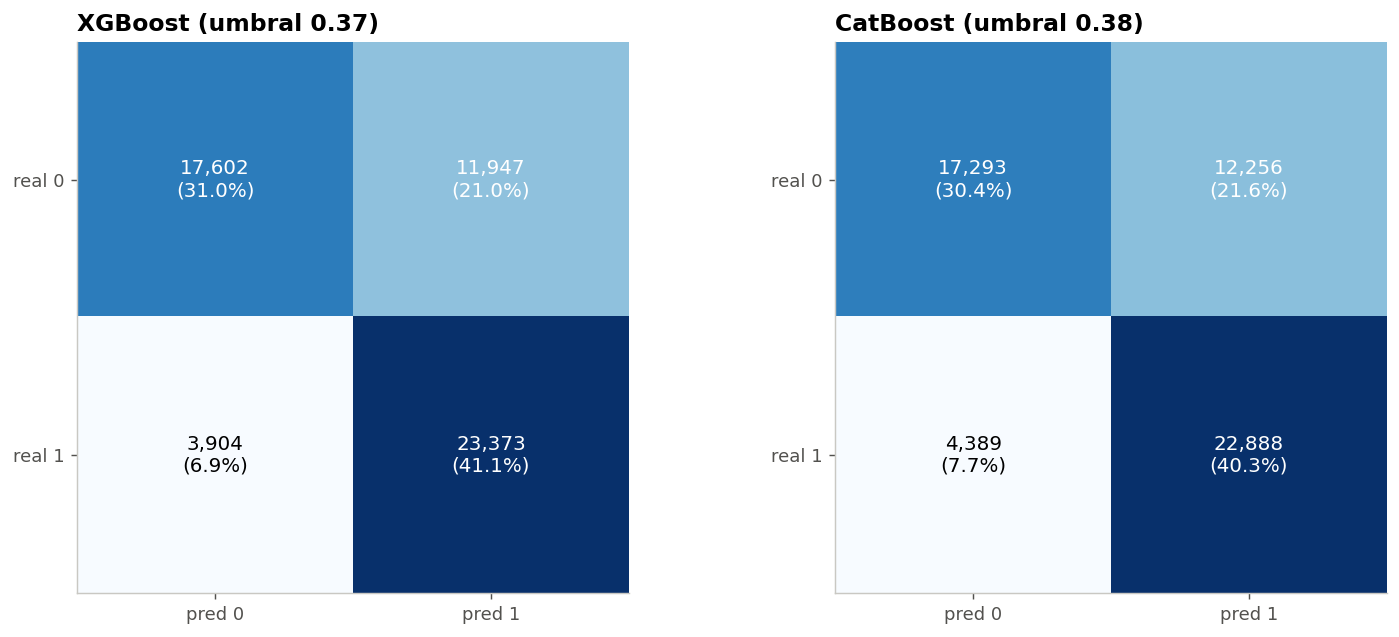

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
matriz(axes[0], y_test, (p_test_xgb >= U_XGB).astype(int), f"XGBoost (umbral {U_XGB:.2f})")
matriz(axes[1], y_test, (p_test_cat >= U_CAT).astype(int), f"CatBoost (umbral {U_CAT:.2f})")
plt.tight_layout(); plt.show()

Curva precisión-recall en `X_test` para ambos modelos. La línea punteada es la precisión de un modelo aleatorio (tasa de la clase 1). El punto marca el umbral elegido.

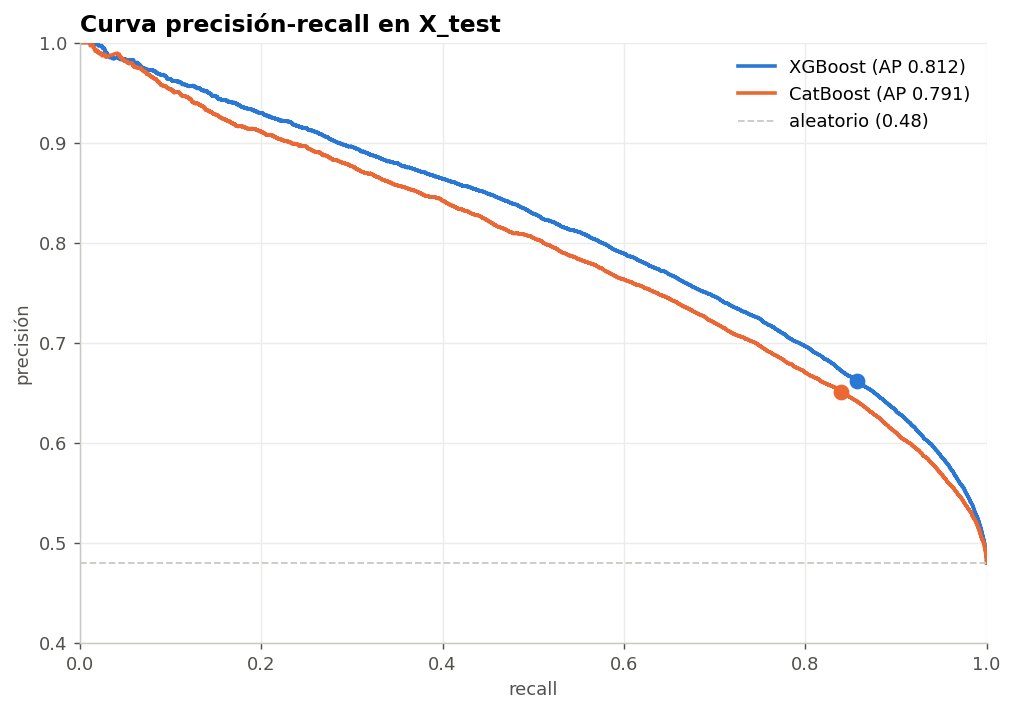

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
for nombre, p, u, col in [("XGBoost", p_test_xgb, U_XGB, C_BLUE), ("CatBoost", p_test_cat, U_CAT, C_ORANGE)]:
    pr, rc, _ = precision_recall_curve(y_test, p)
    ax.plot(rc, pr, color=col, lw=2, label=f"{nombre} (AP {average_precision_score(y_test, p):.3f})")
    pred = p >= u; ax.scatter([recall_score(y_test, pred)], [precision_score(y_test, pred)], color=col, s=60, zorder=3)
ax.axhline(y_test.mean(), color=C_GRAY, ls="--", lw=1, label=f"aleatorio ({y_test.mean():.2f})")
ax.set_xlabel("recall"); ax.set_ylabel("precisión"); ax.set_xlim(0, 1); ax.set_ylim(0.4, 1); ax.legend(frameon=False); ax.set_title("Curva precisión-recall en X_test")
plt.show()

## 6. Modelo final y archivos para Kaggle

Se toma el modelo con mayor F1 en `X_test`, se reentrena con todas las filas etiquetadas (train + val + test) con sus hiperparámetros y su número de árboles, y se califica `oot` con el umbral fijado en `X_val`. Archivos: `outputs/submission_v2.csv` y `outputs/resultado_prueba_v2.csv`.

In [11]:
GANADOR = comp.F1.idxmax()
n_arb = int(comp.loc[GANADOR, "árboles"])
Xc_all = para_cat(X)
if GANADOR == "XGBoost":
    final = xgb.XGBClassifier(**P_XGB, n_estimators=n_arb, tree_method="hist", enable_categorical=True, objective="binary:logistic", random_state=SEED, n_jobs=12)
    final.fit(X, y); p_oot = final.predict_proba(oot[FEATS])[:, 1]; UMBRAL = U_XGB
    final.save_model(str(ROOT / "models" / "xgb_v2.json"))
else:
    final = CatBoostClassifier(**P_CAT, iterations=n_arb, loss_function="Logloss", random_seed=SEED, verbose=False, thread_count=12)
    final.fit(Pool(Xc_all, y, cat_features=CAT)); p_oot = final.predict_proba(Pool(Xc_oot, cat_features=CAT))[:, 1]; UMBRAL = U_CAT
    final.save_model(str(ROOT / "models" / "catboost_v2.cbm"))

ss = pd.read_csv(ROOT / "data" / "sample_submission.csv", usecols=["ID"])
res = ss.merge(pd.DataFrame({"ID": oot.ID.astype(str), "Prob_uno": p_oot}), on="ID", how="left")
res["var_rpta_alt"] = (res.Prob_uno >= UMBRAL).astype(int)
assert res.Prob_uno.notna().all() and len(res) == len(ss)
res[["ID", "var_rpta_alt"]].to_csv(OUT / "submission_v2.csv", index=False)
res[["ID", "var_rpta_alt", "Prob_uno"]].round({"Prob_uno": 5}).to_csv(OUT / "resultado_prueba_v2.csv", index=False, encoding="utf-8")
print(f"Ganador: {GANADOR} | árboles {n_arb} | umbral {UMBRAL:.2f} | % predicho 1 en oot: {res.var_rpta_alt.mean():.3f} | prob media {res.Prob_uno.mean():.3f}")

Ganador: XGBoost | árboles 1500 | umbral 0.37 | % predicho 1 en oot: 0.574 | prob media 0.449


```
python -m kaggle competitions submit prueba-analitica-modelo-opciones-de-pago-season-3 -f outputs/submission_v2.csv -m "v2 xgb/catboost, 77 vars"
```